import required libraries

In [1]:
import pandas as pd

Load dataset

In [2]:
df=pd.read_csv('New folder/datas & notebooks/amazon-fashion-800k+-user-reviews-dataset.csv')

view

In [3]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchases,target
0,1.0,It say 5 pair when purchasing but only get 2 r...,I was looking for 5 pair and only received 2 p...,[],B07QFTMTLP,B07QFTMTLP,AHASEZ65RESN57BMGRV6QBM5DTIA,1565088068852,0,True,-1
1,1.0,DonÃ¢ÂÂt do it!,Just donÃ¢ÂÂt. These things fell apart after...,[],B0764KKDN1,B0764KKDN1,AE3AMA3QSOHFKV46JJAHTHMMIR6A,1622416429592,0,True,-1
2,1.0,Small,Retuned is too small for me,[],B07J1WHVCP,B07J1WHVCP,AH4CFWQE2HTC5BSWIEF3LVLUFK6A,1565284666220,0,True,-1
3,1.0,Pre-Used When Received,This product came with the sleeves turned insi...,[],B0773JWP64,B0773JWP64,AFEKQFJWST6MVTKEJBQKUUBTWK7A,1581963636172,0,False,-1
4,1.0,Worn once and several places at seams have com...,Worn once and several places at seams have com...,[],B099NST9RX,B08JGNS1NK,AGU2FPKN6ARXUSSGBT6WTVLZKJSQ,1640895438476,0,True,-1


Inspect

In [4]:
df.shape

(867310, 11)

In [5]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchases', 'target'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867310 entries, 0 to 867309
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   rating              867310 non-null  float64
 1   title               867107 non-null  object 
 2   text                867012 non-null  object 
 3   images              867310 non-null  object 
 4   asin                867310 non-null  object 
 5   parent_asin         867310 non-null  object 
 6   user_id             867310 non-null  object 
 7   timestamp           867310 non-null  int64  
 8   helpful_vote        867310 non-null  int64  
 9   verified_purchases  867310 non-null  bool   
 10  target              867310 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 67.0+ MB


In [7]:
df.describe()

,rating,timestamp,helpful_vote,target
count,867310.000000,8.673100e+05,867310.000000,867310.000000
mean,3.000000,1.544417e+12,0.563369,0.000000
std,1.414214,7.113754e+10,3.458410,0.894428
min,1.000000,1.020736e+12,0.000000,-1.000000
25%,2.000000,1.492892e+12,0.000000,-1.000000
50%,3.000000,1.545679e+12,0.000000,0.000000
75%,4.000000,1.601400e+12,0.000000,1.000000
max,5.000000,1.694129e+12,954.000000,1.000000


Checking missing values

In [8]:
df.isnull().sum()

rating                  0
title                 203
text                  298
images                  0
asin                    0
parent_asin             0
user_id                 0
timestamp               0
helpful_vote            0
verified_purchases      0
target                  0
dtype: int64

dropping rows with nulls

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

rating                0
title                 0
text                  0
images                0
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote          0
verified_purchases    0
target                0
dtype: int64

check duplicates

In [11]:
df.duplicated().sum()

5264

drop duplicates

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

0

dropping unneccesary columns 

In [14]:
df.drop(['title','images','asin','parent_asin','user_id','timestamp','helpful_vote','verified_purchases','target'],axis=1,inplace=True)

In [15]:
df.head()

,rating,text
0,1.0,I was looking for 5 pair and only received 2 p...
1,1.0,Just donÃ¢ÂÂt. These things fell apart after...
2,1.0,Retuned is too small for me
3,1.0,This product came with the sleeves turned insi...
4,1.0,Worn once and several places at seams have com...


Renaming Columns

In [16]:
df.rename(columns={'text':'Review','rating':'Rating'},inplace=True)

In [17]:
df.head()

,Rating,Review
0,1.0,I was looking for 5 pair and only received 2 p...
1,1.0,Just donÃ¢ÂÂt. These things fell apart after...
2,1.0,Retuned is too small for me
3,1.0,This product came with the sleeves turned insi...
4,1.0,Worn once and several places at seams have com...


In [18]:
df.shape

(861596, 2)

visualizations of data distributions

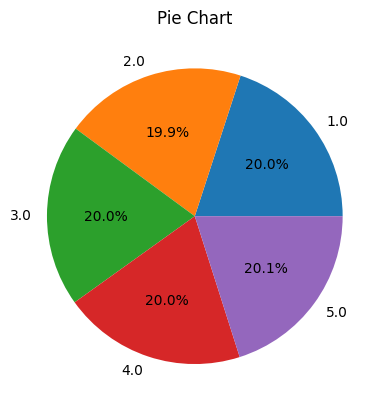

In [19]:
#pie chart visulize of data distribution
import matplotlib.pyplot as plt
rating_counts = df['Rating'].value_counts().sort_index()
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.show()

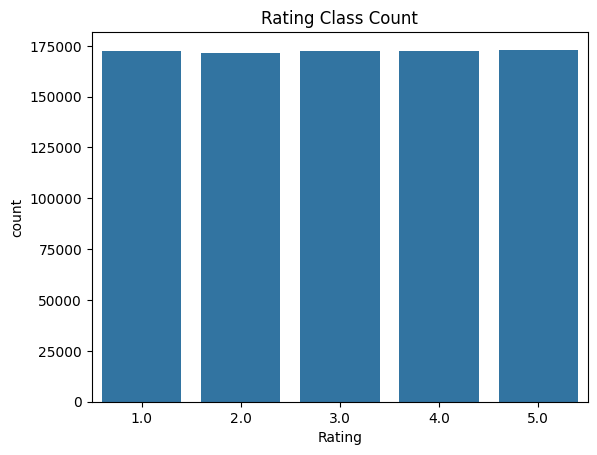

In [20]:
#Count plot (for categorical data)
import seaborn as sns
sns.countplot(x='Rating', data=df)
plt.title("Rating Class Count")
plt.show()

special character removal

In [21]:
import re

# Example: cleaning the review text

def clean_review(text):
    if pd.isnull(text):
        return ""

    # Remove emojis
    text = re.sub(r'[^\w\s,]', '', text.encode('ascii', 'ignore').decode('ascii'))
    
    # Remove special characters and digits (keep letters and basic punctuation if needed)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to the column
df['Review'] = df['Review'].astype(str).apply(clean_review)

# View cleaned data
print(df[['Review', 'Review']].head())

                                              Review  \
0  i was looking for pair and only received pair ...   
1  just dont these things fell apart after the fi...   
2                        retuned is too small for me   
3  this product came with the sleeves turned insi...   
4  worn once and several places at seams have com...   

                                              Review  
0  i was looking for pair and only received pair ...  
1  just dont these things fell apart after the fi...  
2                        retuned is too small for me  
3  this product came with the sleeves turned insi...  
4  worn once and several places at seams have com...  


check and remove conflicting remove

In [22]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [23]:
#checking conflicting reviews
from textblob import TextBlob

# Get sentiment polarity for each review (-1 = negative, 1 = positive)
df['Polarity'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Optional: classify sentiment direction
def classify_sentiment(p):
    if p > 0.2:
        return 'positive'
    elif p < -0.2:
        return 'negative'
    else:
        return 'neutral'

df['Sentiment'] = df['Polarity'].apply(classify_sentiment)

In [24]:
# Define conflict conditions
conflict_mask = (
    ((df['Rating'] >= 4) & (df['Sentiment'] == 'negative')) |
    ((df['Rating'] <= 2) & (df['Sentiment'] == 'positive'))
)

# Get conflicting reviews for optional inspection
conflicting_reviews = df[conflict_mask]

# Remove conflicting reviews
cleaned_df = df[~conflict_mask].reset_index(drop=True)

print("Original size:", len(df))
print("After removing conflicts:", len(cleaned_df))


Original size: 861596
After removing conflicts: 786119


In [25]:
cleaned_df.head()

,Rating,Review,Polarity,Sentiment
0,1.0,i was looking for pair and only received pair ...,-0.100,neutral
1,1.0,just dont these things fell apart after the fi...,-0.125,neutral
2,1.0,retuned is too small for me,-0.250,negative
3,1.0,this product came with the sleeves turned insi...,0.000,neutral
4,1.0,worn once and several places at seams have com...,0.000,neutral


In [26]:
#drop unnecessary columns
cleaned_df.drop(['Polarity','Sentiment'],axis=1,inplace=True)

In [27]:
cleaned_df.head()

,Rating,Review
0,1.0,i was looking for pair and only received pair ...
1,1.0,just dont these things fell apart after the fi...
2,1.0,retuned is too small for me
3,1.0,this product came with the sleeves turned insi...
4,1.0,worn once and several places at seams have com...


In [28]:
cleaned_df.shape

(786119, 2)

stop word removal

In [29]:
#install & import required libraries
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
#defining stopword removal function
stop_words = set(stopwords.words('english'))
punctuations = string.punctuation

def remove_stopwords(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in punctuations])
    # Tokenize and remove stopwords
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

In [31]:
#apply function to data
cleaned_df['Review'] = cleaned_df['Review'].astype(str).apply(remove_stopwords)

In [32]:
cleaned_df.head()

,Rating,Review
0,1.0,looking pair received pair tho paid pair two p...
1,1.0,dont things fell apart first wash uncomfortabl...
2,1.0,retuned small
3,1.0,product came sleeves turned inside lots stray ...
4,1.0,worn several places seams come apart leaving h...


Lemmatization

In [33]:
#required libraries
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [34]:
#defining lemmatization function
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

In [35]:
#apply function on balanced data
cleaned_df['Review'] = cleaned_df['Review'].apply(lemmatize_text)

In [36]:
#view
cleaned_df['Review'].head()

0    looking pair received pair tho paid pair two p...
1    dont thing fell apart first wash uncomfortable...
2                                        retuned small
3    product came sleeve turned inside lot stray wh...
4    worn several place seam come apart leaving hol...
Name: Review, dtype: object

Filter out long & short reviews

In [37]:
# Count reviews with fewer than 3 words
short_reviews_count = cleaned_df['Review'].apply(lambda x: len(x.split()) < 3).sum()

# Count reviews with more than 100 words (or any threshold you prefer)
long_reviews_count = cleaned_df['Review'].apply(lambda x: len(x.split()) > 100).sum()

print(f"Reviews with fewer than 3 words: {short_reviews_count}")
print(f"Reviews with more than 100 words: {long_reviews_count}")

Reviews with fewer than 3 words: 87508
Reviews with more than 100 words: 4921


In [38]:
# Keep only reviews that have word count between 3 and 100
filtered_df = cleaned_df[cleaned_df['Review'].apply(lambda x: 3 <= len(x.split()) <= 100)].reset_index(drop=True)

In [39]:
#rating class distribution
filtered_df['Rating'].value_counts().sort_index()

Rating
1.0    128648
2.0    116977
3.0    157092
4.0    149818
5.0    141155
Name: count, dtype: int64

In [40]:
#check duplicates
filtered_df.duplicated().sum()

10077

In [41]:
#remove duplicate
filtered_df.drop_duplicates(inplace=True)

In [42]:
filtered_df.shape

(683613, 2)

shuffle data

In [43]:
filtered_df= filtered_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [44]:
filtered_df.head()

,Rating,Review
0,3.0,would given star back shirt isnt pictured pict...
1,3.0,cutest legging ever fit perfect month old gran...
2,5.0,everything say love thanks
3,4.0,picture lack structure leather part rather scu...
4,2.0,guess belt cant handle line dancing second tim...


samples of each rating

In [45]:
for rating in sorted(filtered_df['Rating'].unique()):
    print(f"\n Rating: {int(rating)}")
    samples = filtered_df[filtered_df['Rating'] == rating].sample(3, random_state=42)
    for i, review in enumerate(samples['Review'].values, 1):
        print(f"{i}. {review}\n")


 Rating: 1
1. keep seeing everyone say true size mine small even ordered size theyd loose fit snug exactly fit wanted stick dry hand returning

2. lens terrible rest construction good

3. brand victorinox good know carry received flaw checked trip came serious flaw zipper broke couldnt fix naples italy buy another emergency one think seller sold carry failed fault detected lost moneybr felix


 Rating: 2
1. product one size pretty big also terrible plastic smell took bag picture make look soft unfortunately returning item

2. broke within two us wearing plastic durable

3. look cute wish bar little longer hook anchor dug inside navel tip ended falling week got


 Rating: 3
1. cute shirt fit little small

2. worn costume party bought semiformal roaring party looked liffle cheap event planning wear also little sheer pretty dress though

3. wanted small drop pearl earring year thought looked exquisite online husband bought vday gift really like well crafted beautiful pearl size perfect w

visualization after cleaning

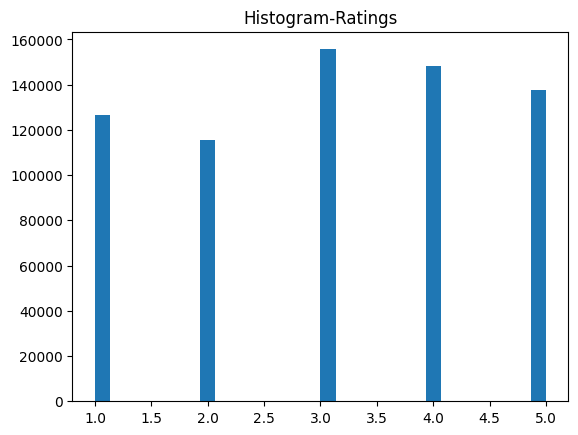

In [46]:
#histogram
import matplotlib.pyplot as plt
#histogram of rating
plt.hist(filtered_df['Rating'],bins=30)
plt.title('Histogram-Ratings')
plt.show()

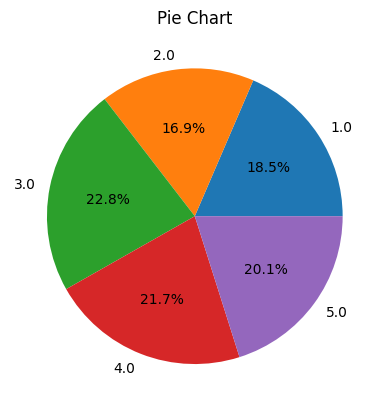

In [47]:
#pie chart visulize of data distribution
import matplotlib.pyplot as plt
rating_counts = filtered_df['Rating'].value_counts().sort_index()
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.show()

save data

In [48]:
filtered_df.to_csv('final_data.csv')